# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

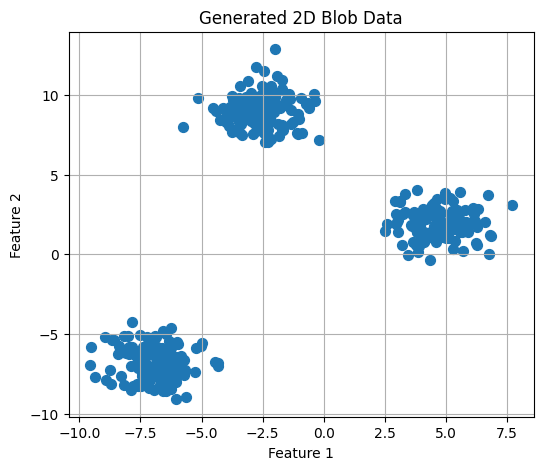

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


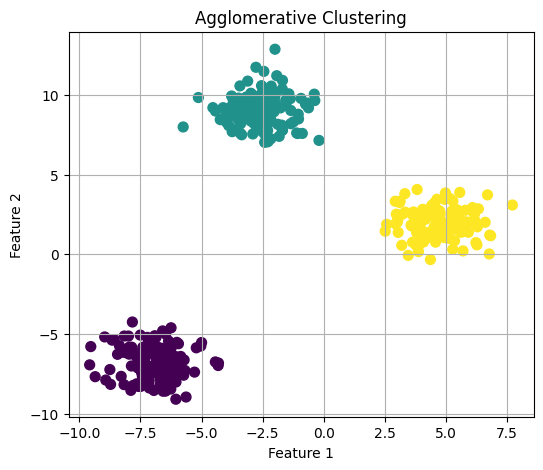

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

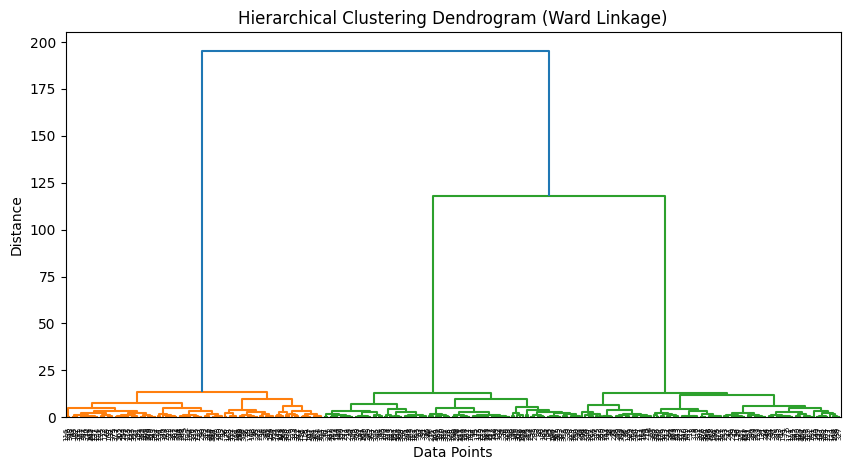

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [149]:
df = pd.read_csv("CC GENERAL.csv")
df.head()
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [150]:
#Identify Numeric vs Categorical Features
numeric_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

#printing all numeric features
print("Numeric Features:", list(numeric_features))

#printing all categorical features
print("Categorical Features:", list(categorical_features))

Numeric Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Categorical Features: ['CUST_ID']


In [152]:

#Distribution of Numeric Features(min, max, mean, std, skewness)
display(df[numeric_features].describe())

#Skewness
display(df[numeric_features].skew())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


,0
BALANCE,2.393386
BALANCE_FREQUENCY,-2.023266
PURCHASES,8.144269
ONEOFF_PURCHASES,10.045083
INSTALLMENTS_PURCHASES,7.299120
CASH_ADVANCE,5.166609
PURCHASES_FREQUENCY,0.060164
ONEOFF_PURCHASES_FREQUENCY,1.535613
PURCHASES_INSTALLMENTS_FREQUENCY,0.509201
CASH_ADVANCE_FREQUENCY,1.828686


In [153]:
#since CUST_ID is an identifier, not a behavioral feature, It can negatively affect clustering quality
#so the first step on data preperation "Drop irrelevant or target columns" i will do it here
df['CUST_ID'].nunique()
df = df.drop('CUST_ID', axis=1)

In [154]:
#Check Missing / Unknown Values
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [155]:
# Handle Missing Values using Mean imputation
df.fillna(df.mean(), inplace=True)
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


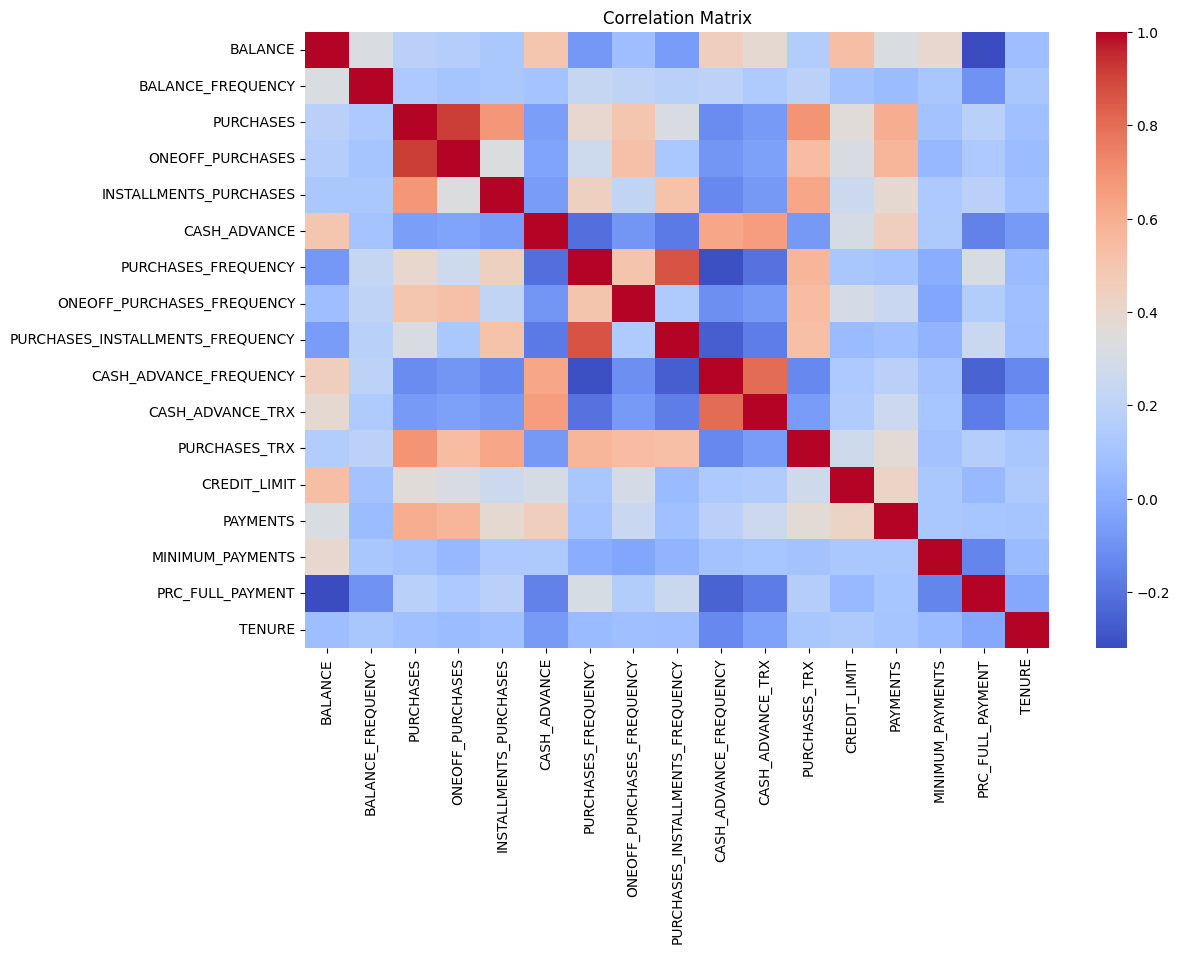

In [156]:
#Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

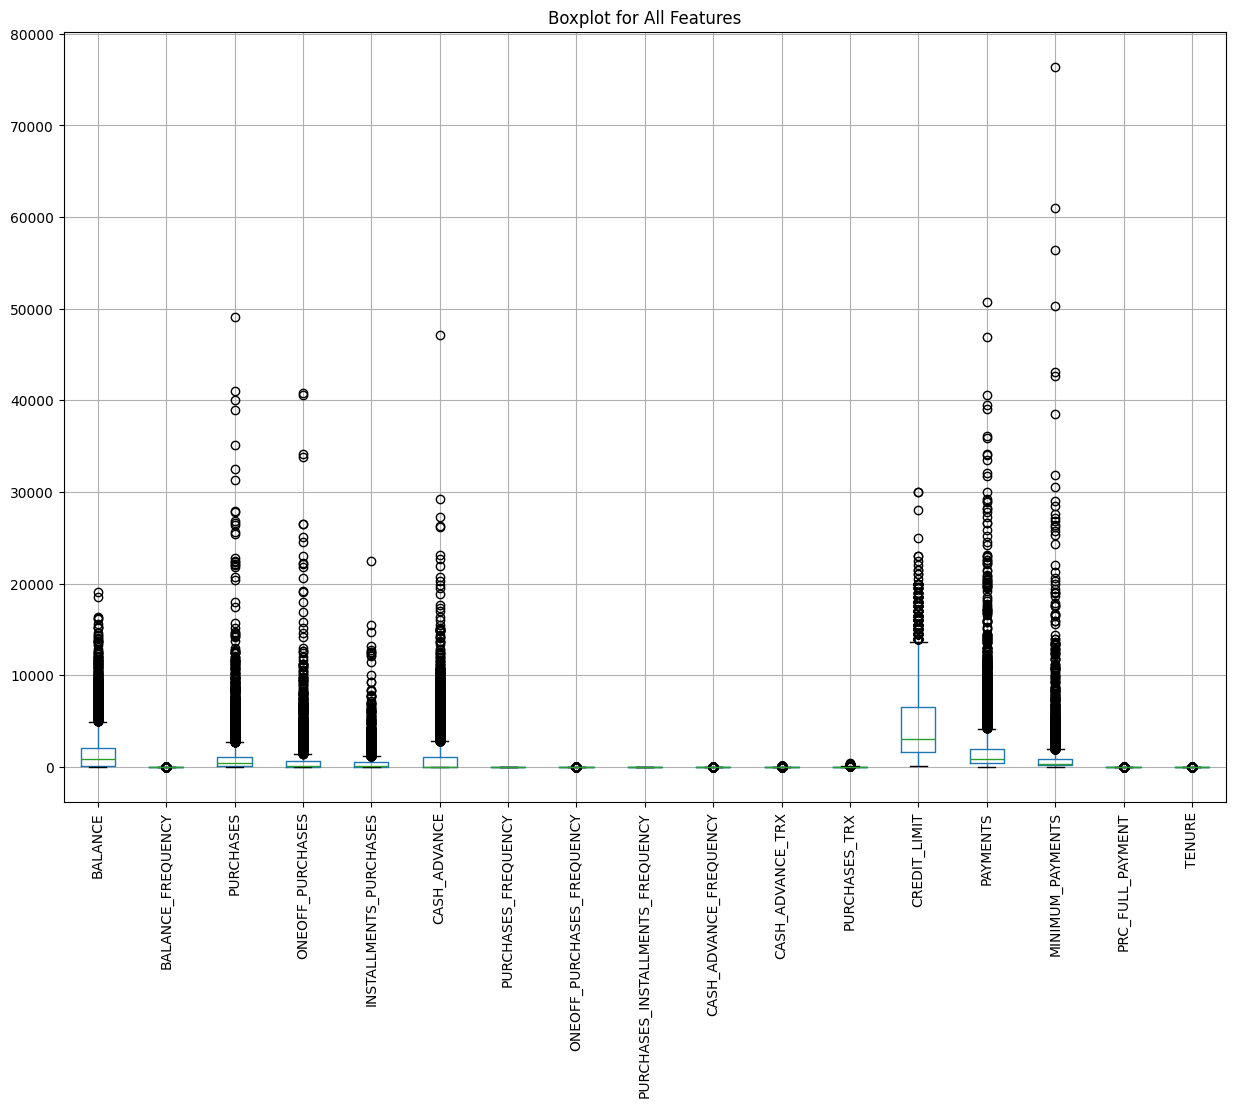

In [157]:
#Identify Outliers (Boxplots)
plt.figure(figsize=(15,10))
df.boxplot(rot=90)
plt.title("Boxplot for All Features")
plt.show()

## **2. Data Preparation**

In [158]:
#Drop Target & Irrelevant Columns
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [159]:
#Scale Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
display(scaled_data)

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

In [160]:
#Final Check
pd.DataFrame(scaled_data).isnull().sum().sum()

np.int64(0)

## **3. Apply Agglomerative Clustering**

In [175]:
# to ensure it always get the same random sample
np.random.seed(42)

#Randomly selects 3000 customers from the dataset
sample_idx = np.random.choice(len(scaled_data), size=3000, replace=False)

#Prevents selecting the same row twice
scaled_sample = scaled_data[sample_idx]

In [176]:
# Find the best number of clusters using Silhouette Score
print("Silhouette Scores for different number of clusters:")
silhouette_scores = {}
for n in range(2, 7):
    agg_temp = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='ward')
    temp_labels = agg_temp.fit_predict(scaled_sample)
    s = silhouette_score(scaled_sample, temp_labels)
    silhouette_scores[n] = s
    print(f"  n_clusters={n} → Silhouette Score: {s:.4f}")

best_n = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest number of clusters: {best_n}")



Silhouette Scores for different number of clusters:
  n_clusters=2 → Silhouette Score: 0.2879
  n_clusters=3 → Silhouette Score: 0.2630
  n_clusters=4 → Silhouette Score: 0.2394
  n_clusters=5 → Silhouette Score: 0.1423
  n_clusters=6 → Silhouette Score: 0.1621

Best number of clusters: 2


In [177]:
#AgglomerativeClustering using the best number of clusters=2
agg = AgglomerativeClustering(
    n_clusters=best_n,
    metric='euclidean',
    linkage='ward'
)

# Fit and predict cluster labels(Assigns each customer to a cluster)
labels = agg.fit_predict(scaled_sample)

#How many customers are in each cluster
print("\nCluster label counts:")
print(pd.Series(labels).value_counts().sort_index())


Cluster label counts:
0     484
1    2516
Name: count, dtype: int64


## **4. Visualize the Clustering Results**

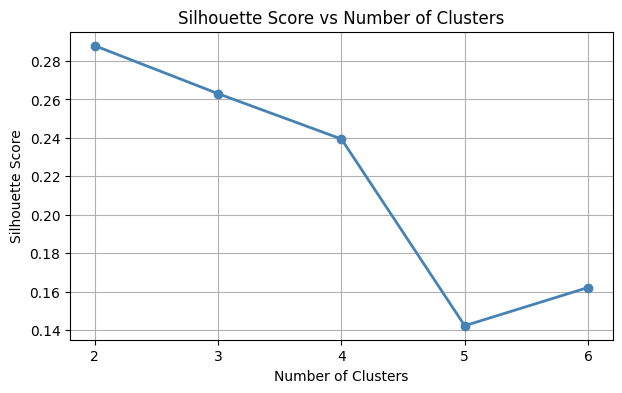

In [178]:
# Silhouette Score vs Number of Clusters
plt.figure(figsize=(7,4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='steelblue', linewidth=2)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(list(silhouette_scores.keys()))
plt.grid(True)
plt.show()

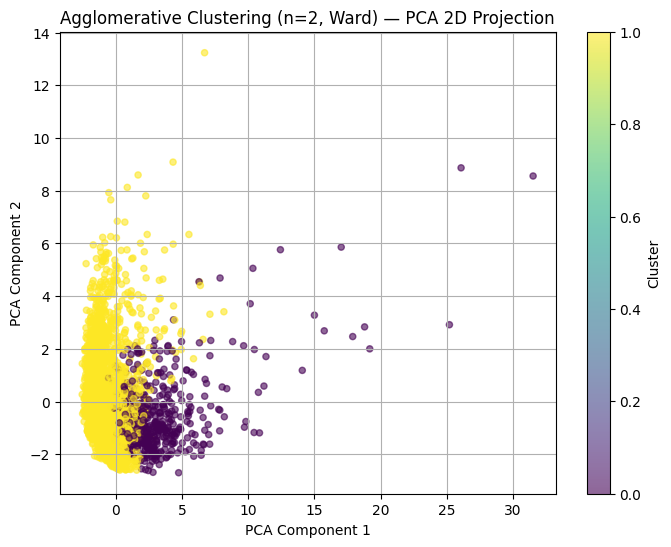

In [179]:
# PCA to reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(scaled_sample)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='viridis', s=20, alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Agglomerative Clustering (n={best_n}, Ward) — PCA 2D Projection")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

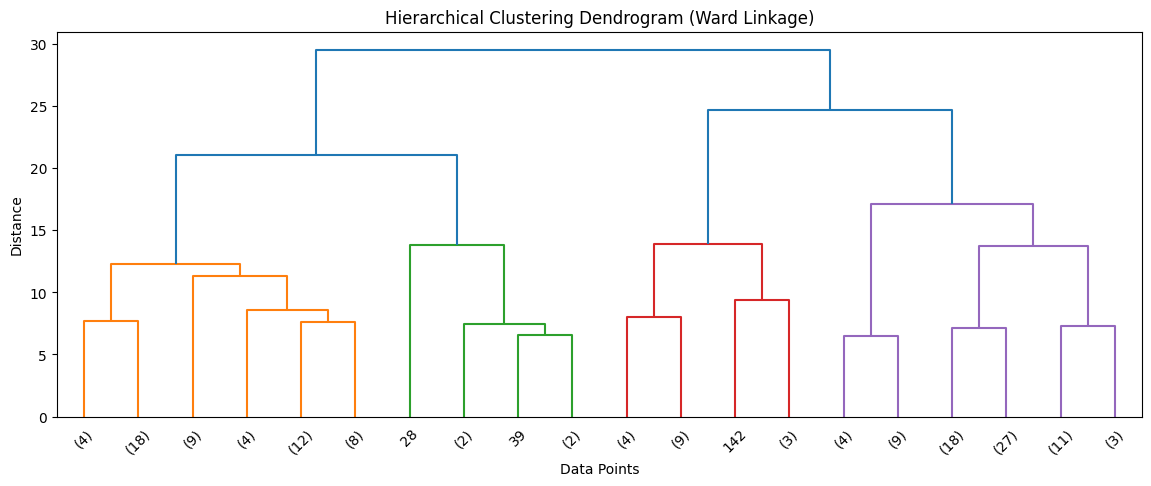

In [180]:
# Dendrogram on a sub-sample of 150 points for readability
np.random.seed(42)
sub_idx = np.random.choice(len(scaled_sample), size=150, replace=False)
scaled_sub = scaled_sample[sub_idx]

Z = linkage(scaled_sub, method='ward', metric='euclidean')

plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


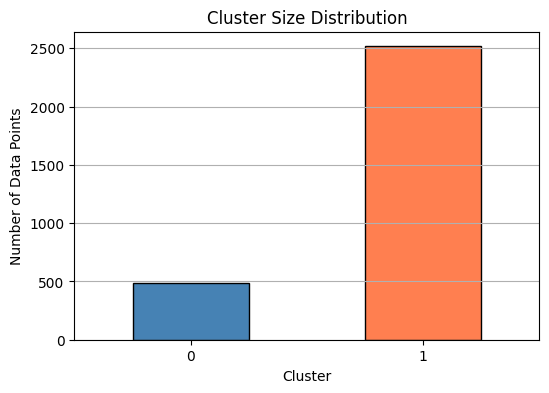

In [181]:
# Cluster Size Distribution
plt.figure(figsize=(6,4))
pd.Series(labels).value_counts().sort_index().plot(kind='bar', color=['steelblue','coral','seagreen','orchid','gold'][:best_n], edgecolor='black')
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Data Points")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## **5. Evaluate the Clustering**

In [182]:
# Silhouette Score
score = silhouette_score(scaled_sample, labels)
print(f"Silhouette Score (n_clusters={best_n}, ward, euclidean): {score:.4f}")


Silhouette Score (n_clusters=2, ward, euclidean): 0.2879


In [183]:
# Compare linkage methods
print("\nSilhouette Scores by Linkage Method:")
for lnk in ['ward', 'complete', 'average']:
    agg_cmp = AgglomerativeClustering(n_clusters=best_n, metric='euclidean', linkage=lnk)
    lbl_cmp = agg_cmp.fit_predict(scaled_sample)
    s = silhouette_score(scaled_sample, lbl_cmp)
    print(f"  linkage='{lnk}' → Silhouette Score: {s:.4f}")


Silhouette Scores by Linkage Method:
  linkage='ward' → Silhouette Score: 0.2879
  linkage='complete' → Silhouette Score: 0.8156
  linkage='average' → Silhouette Score: 0.8098


## **6. Explain whether the clustering quality and justify your reasoning**

since the Silhouette Score is between 0.2–0.5 hence it is a moderate structure
All features are numeric hence Euclidean distance is meaningful and reliable
Ward linkage minimizes within-cluster variance, producing compact and balanced clusters
Several features such as CASH_ADVANCE, PURCHASES, and BALANCE contain extreme outliers visible in the boxplots.This distorted cluster boundaries and pulled centroids away from the true group center.